# Bootstrap Modalities scaling-law comparison

This notebook plots all eight completed Bootstrap Modalities fits in one paper-style scaling figure. It uses the same `optimal_tokens` and `structural_bits` helpers as `experiments.scaling_laws.graph`, so its $S_T$ and compute-optimal-token curves have the same definitions as the command-line graph.

Set `SCALING_LAWS_FIT_ROOT` to the directory containing the eight fit directories. On the sweep worker, the current results are in `/mnt/nvme1/epiaudio/worktrees/scaling-law-fits-6842278/outputs/scaling_laws`.

In [4]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'epiaudio').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from experiments.scaling_laws.graph import optimal_tokens, structural_bits

FIT_ROOT = Path("/mnt/nvme1/epiaudio/worktrees/scaling-law-fits-6842278/outputs/scaling_laws")
FIT_ROOT

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True


In [5]:
SWEEPS = {
    # 'ASCII96': 'bootstrap_modalities_ascii96__2026-08-25_18:32:41',
    # 'Puzzles': 'bootstrap_modalities_puzzles__2026-08-25_20:39:46',
    # 'EnCodec': 'bootstrap_modalities_encodec__2026-08-25_22:48:04',
    'OpenWebText': 'bootstrap_modalities_b64_ascii96__2026-08-26_16:29:56',
    'Puzzles': 'bootstrap_modalities_b64_puzzles__2026-08-26_16:29:56',
    'CIFAR-5M': 'bootstrap_modalities_b64_grayscale__2026-08-26_16:29:56',
    'EnCodec': 'bootstrap_modalities_b64_encodec__2026-08-26_16:29:56',
    'XCodec': 'bootstrap_modalities_xcodec_b64_xcodec__2026-08-28_16:30:05',
}


def load_fits(fit_root: Path) -> dict[str, dict[str, object]]:
    fits: dict[str, dict[str, object]] = {}
    missing: list[Path] = []
    for label, sweep_name in SWEEPS.items():
        path = fit_root / sweep_name / 'fit.json'
        if not path.is_file():
            missing.append(path)
            continue
        fit = json.loads(path.read_text())
        if fit['sweep_name'] != sweep_name:
            raise ValueError(f'{path}: expected {sweep_name!r}, found {fit["sweep_name"]!r}')
        fits[label] = fit
    if missing:
        paths = '\n'.join(str(path) for path in missing)
        raise FileNotFoundError(f'Missing fitted results; set SCALING_LAWS_FIT_ROOT.\n{paths}')
    return fits


fits = load_fits(FIT_ROOT)
[(label, fit['observations'], fit['huber_loss']) for label, fit in fits.items()]


[('OpenWebText', 192, 0.01148838431786105),
 ('Puzzles', 192, 0.017127194050673533),
 ('CIFAR-5M', 192, 0.004328589496477811),
 ('EnCodec', 192, 0.009326284142728347),
 ('XCodec', 192, 0.003901742647699266)]

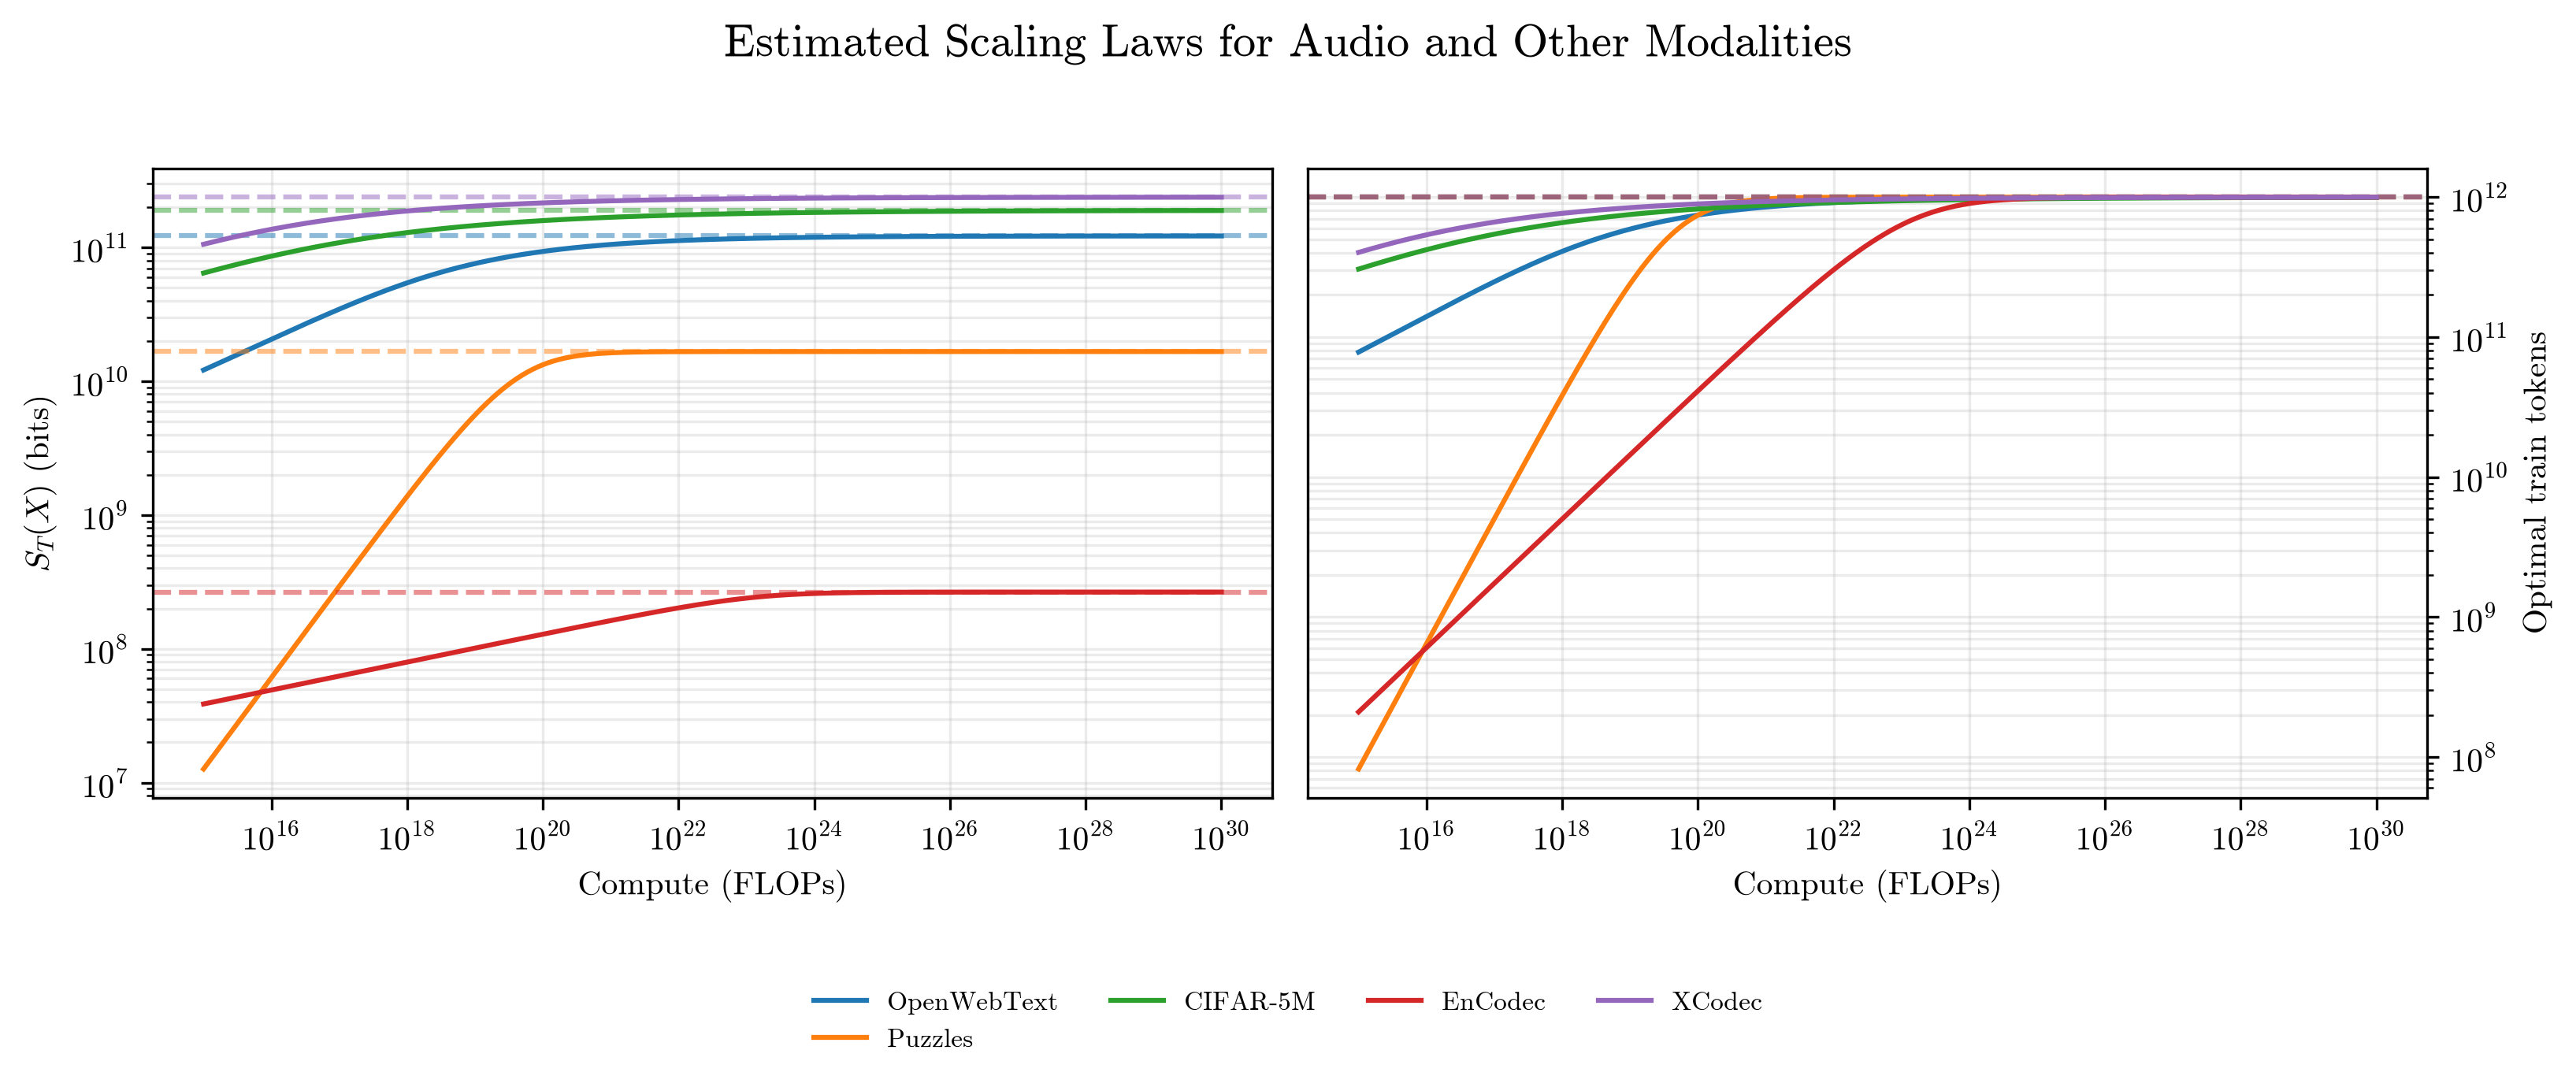

In [6]:
DATA_TOKENS = 1e12
COMPUTE = np.geomspace(1e15, 1e30, 400)

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True,  dpi=300)
for label, fit in fits.items():
    points = []
    for compute in COMPUTE:
        try:
            tokens = optimal_tokens(
                compute, float(fit['alpha']), float(fit['beta']),
                float(fit['N0']), float(fit['D0']), DATA_TOKENS,
            )
        except ValueError:
            continue
        points.append((compute, tokens))
    values, tokens = np.asarray(points).T
    line = axes[0].plot(
        values,
        [structural_bits(token, float(fit['beta']), float(fit['D0'])) for token in tokens],
        label=label,
    )[0]
    axes[0].axhline(
        structural_bits(DATA_TOKENS, float(fit['beta']), float(fit['D0'])),
        color=line.get_color(), ls='--', alpha=0.5,
    )
    axes[1].plot(values, tokens, color=line.get_color())
    axes[1].axhline(DATA_TOKENS, color=line.get_color(), ls='--', alpha=0.5)

axes[0].set(ylabel=r'$S_T(X)$ (bits)', xlabel='Compute (FLOPs)')
axes[1].set(ylabel='Optimal train tokens', xlabel='Compute (FLOPs)')
for axis in axes:
    axis.set(xscale='log', yscale='log')
    axis.grid(True, which='both', alpha=0.25)
axes[1].yaxis.set_label_position('right')
axes[1].yaxis.tick_right()
figure.legend(*axes[0].get_legend_handles_labels(), loc='lower center', ncols=4, frameon=False, fontsize=8)
figure.suptitle('Estimated Scaling Laws for Audio and Other Modalities', fontsize=14)
figure.tight_layout(rect=(0, 0.12, 1, 0.95))
plt.show( )
